In [2]:
import os
os.environ['PYSPARK_PYTHON']='python'

In [3]:
from pyspark.sql import SparkSession

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import matplotlib.pyplot as plt

# Initialize Spark
spark = SparkSession.builder \
    .appName("HR_Attrition_Pipeline") \
    .getOrCreate()
# --- 3.1 Data Loading ---
hdfs_path = "hdfs://localhost:9000/user/abhimanyu-tamang/dataset.csv"
df = spark.read.csv(hdfs_path, header=True, inferSchema=True)
df.show(5)
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/08 19:53:59 WARN Utils: Your hostname, Acer, resolves to a loopback address: 127.0.1.1; using 10.134.209.185 instead (on interface wlp42s0)
26/03/08 19:53:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/08 19:53:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/08 19:54:06 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+---------+-----------------+---------+--------------------+----------------+---------+--------------+-------------+--------------+-----------------------+------+----------+--------------+--------+--------------------+---------------+-------------+-------------+-----------+------------------+------+--------+-----------------+-----------------+------------------------+-------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|Age|Attrition|   BusinessTravel|DailyRate|          Department|DistanceFromHome|Education|EducationField|EmployeeCount|EmployeeNumber|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|JobLevel|             JobRole|JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|Over18|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StandardHours|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBalanc

In [5]:
df.createOrReplaceTempView("dataset")
query = """SELECT * FROM dataset"""
result = spark.sql(query)
result.show()

+---+---------+-----------------+---------+--------------------+----------------+---------+--------------+-------------+--------------+-----------------------+------+----------+--------------+--------+--------------------+---------------+-------------+-------------+-----------+------------------+------+--------+-----------------+-----------------+------------------------+-------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|Age|Attrition|   BusinessTravel|DailyRate|          Department|DistanceFromHome|Education|EducationField|EmployeeCount|EmployeeNumber|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|JobLevel|             JobRole|JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|Over18|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StandardHours|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBalanc

In [6]:
# Query 1: Benchmarking Salary against Job Role Average
query1 = """
SELECT *, 
       AVG(MonthlyIncome) OVER(PARTITION BY JobRole) as Avg_Role_Income,
       (MonthlyIncome - AVG(MonthlyIncome) OVER(PARTITION BY JobRole)) as Salary_Gap
FROM dataset
"""
df_final = spark.sql(query1)
df_final.createOrReplaceTempView("dataset_ml") 
spark.sql("""
SELECT Attrition, 
       COUNT(*) as Total_Count, 
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as Percentage
FROM dataset_ml
GROUP BY Attrition
""").show()

26/03/08 19:54:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+-----------+----------+
|Attrition|Total_Count|Percentage|
+---------+-----------+----------+
|       No|       1233|     83.88|
|      Yes|        237|     16.12|
+---------+-----------+----------+



26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [7]:
# Query 2: Attrition Distribution Percentage
spark.sql("""
SELECT Attrition, 
       COUNT(*) as Total_Count, 
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as Percentage
FROM dataset_ml
GROUP BY Attrition
""").show()

26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+-----------+----------+
|Attrition|Total_Count|Percentage|
+---------+-----------+----------+
|       No|       1233|     83.88|
|      Yes|        237|     16.12|
+---------+-----------+----------+



26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/08 19:54:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [8]:
# Query 3: Multi-Factor Attrition Analysis
spark.sql("""
SELECT Department, JobRole, OverTime,
       ROUND(AVG(JobSatisfaction), 2) as Avg_Satisfaction,
       ROUND(AVG(MonthlyIncome), 2) as Avg_Income,
       COUNT(CASE WHEN Attrition = 'Yes' THEN 1 END) as Attrition_Count
FROM dataset_ml
GROUP BY Department, JobRole, OverTime
ORDER BY Attrition_Count DESC
""").show(10)

+--------------------+--------------------+--------+----------------+----------+---------------+
|          Department|             JobRole|OverTime|Avg_Satisfaction|Avg_Income|Attrition_Count|
+--------------------+--------------------+--------+----------------+----------+---------------+
|Research & Develo...|  Research Scientist|     Yes|            2.66|   3287.96|             33|
|Research & Develo...|Laboratory Techni...|      No|            2.69|   3195.23|             31|
|               Sales|     Sales Executive|     Yes|            2.93|   7068.46|             31|
|Research & Develo...|Laboratory Techni...|     Yes|            2.71|   3370.42|             31|
|               Sales|     Sales Executive|      No|            2.69|   6865.86|             26|
|               Sales|Sales Representative|      No|            2.66|   2671.92|             17|
|               Sales|Sales Representative|     Yes|            2.92|   2513.13|             16|
|Research & Develo...|  Resear

In [9]:
# Query 4: Identifying High-Risk Demographics
spark.sql("""
SELECT EducationField, Gender, 
       COUNT(*) as Employee_Count,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Leavers
FROM dataset_ml
WHERE JobSatisfaction < 2 AND OverTime = 'Yes'
GROUP BY EducationField, Gender
HAVING Leavers > 0
ORDER BY Leavers DESC
""").show()

+----------------+------+--------------+-------+
|  EducationField|Gender|Employee_Count|Leavers|
+----------------+------+--------------+-------+
|   Life Sciences|  Male|            15|      6|
|   Life Sciences|Female|            17|      6|
|         Medical|  Male|            19|      5|
|         Medical|Female|            15|      3|
|       Marketing|  Male|             3|      2|
| Human Resources|  Male|             2|      2|
|Technical Degree|  Male|             3|      2|
|Technical Degree|Female|             2|      1|
| Human Resources|Female|             1|      1|
|       Marketing|Female|             3|      1|
|           Other|  Male|             4|      1|
+----------------+------+--------------+-------+



In [10]:
# Query 5: Career Stagnation Analysis
spark.sql("""
SELECT EmployeeNumber, YearsAtCompany, YearsSinceLastPromotion,
       (YearsAtCompany - YearsSinceLastPromotion) as Years_Stability,
       Attrition
FROM dataset_ml
WHERE YearsAtCompany > 5
ORDER BY YearsSinceLastPromotion DESC
""").show(10)

+--------------+--------------+-----------------------+---------------+---------+
|EmployeeNumber|YearsAtCompany|YearsSinceLastPromotion|Years_Stability|Attrition|
+--------------+--------------+-----------------------+---------------+---------+
|          1204|            26|                     15|             11|       No|
|          1042|            17|                     15|              2|      Yes|
|          1373|            19|                     15|              4|       No|
|           162|            20|                     15|              5|       No|
|           165|            40|                     15|             25|      Yes|
|          1278|            33|                     15|             18|       No|
|           329|            33|                     15|             18|       No|
|          1293|            21|                     15|              6|       No|
|           981|            17|                     15|              2|       No|
|          1307|

In [11]:
# 1. Categorical columns (Department, JobRole, etc.)
categorical_cols = ["BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]

# 2. StringIndexer & OneHotEncoder Pipeline
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_cols]
encoder = OneHotEncoder(
    inputCols=[c+"_idx" for c in categorical_cols], 
    outputCols=[c+"_vec" for c in categorical_cols]
)

# 3. Numeric Columns (Retention of key variables)
numeric_cols = ["Age", "DistanceFromHome", "JobSatisfaction", "MonthlyIncome", "Salary_Gap"]

# 4. Assemble into Feature Vector
assembler = VectorAssembler(
    inputCols=[c+"_vec" for c in categorical_cols] + numeric_cols, 
    outputCol="features"
)

# 5. Target Label
label_indexer = StringIndexer(inputCol="Attrition", outputCol="label")

In [12]:
# --- Step 1: Data Splitting ---
train_data, test_data = df_final.randomSplit([0.7, 0.3], seed=42)

# --- Step 2: Pipeline Fit ---
# Note: Use the corrected order [indexers + [encoder, assembler, label_indexer, rf]]
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100)
pipeline = Pipeline(stages=indexers + [encoder, assembler, label_indexer, rf])
model = pipeline.fit(train_data)

# --- Step 3: Generate Predictions ---
predictions = model.transform(test_data)

Testing Random Forest with 10 trees (Optimizing F1-Score)...
Testing Random Forest with 50 trees (Optimizing F1-Score)...
Testing Random Forest with 100 trees (Optimizing F1-Score)...
Testing Random Forest with 200 trees (Optimizing F1-Score)...


26/03/08 19:54:33 WARN DAGScheduler: Broadcasting large task binary with size 1056.5 KiB
26/03/08 19:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1173.1 KiB
26/03/08 19:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1173.1 KiB


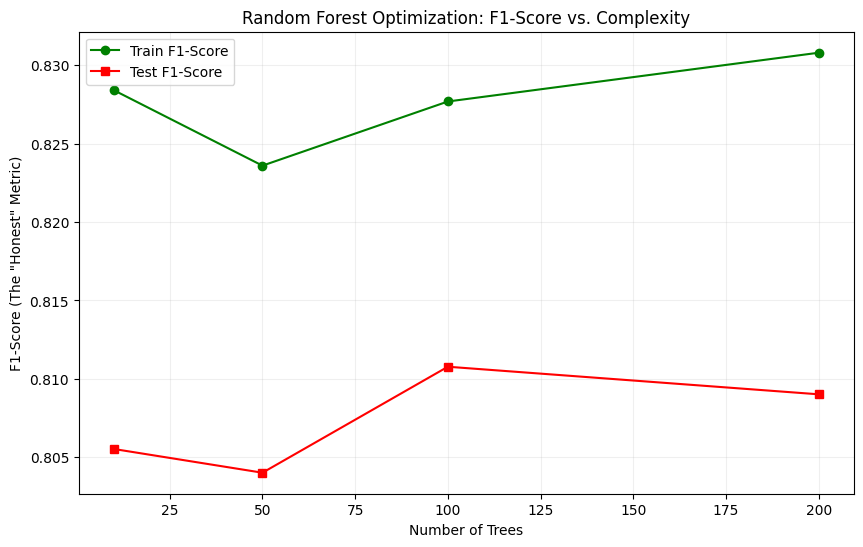

In [13]:
# 1. Prepare data once to save HDFS/Spark resources
preprocessing_pipeline = Pipeline(stages=indexers + [encoder, label_indexer, assembler])
preprocessing_model = preprocessing_pipeline.fit(train_data)
train_transformed = preprocessing_model.transform(train_data)
test_transformed = preprocessing_model.transform(test_data)

n_trees = [10, 50, 100, 200]
train_f1 = []
test_f1 = []

# 2. Iterate and evaluate using F1-Score
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

for n in n_trees:
    print(f"Testing Random Forest with {n} trees (Optimizing F1-Score)...")
    rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=n, seed=42)
    rf_model = rf.fit(train_transformed)
    
    # Calculate F1 for Train and Test
    train_f1.append(evaluator_f1.evaluate(rf_model.transform(train_transformed)))
    test_f1.append(evaluator_f1.evaluate(rf_model.transform(test_transformed)))

# 3. Plotting the "Honest" Curve
plt.figure(figsize=(10, 6))
plt.plot(n_trees, train_f1, marker='o', color='green', label='Train F1-Score')
plt.plot(n_trees, test_f1, marker='s', color='red', label='Test F1-Score')

plt.xlabel('Number of Trees')
plt.ylabel('F1-Score (The "Honest" Metric)')
plt.title('Random Forest Optimization: F1-Score vs. Complexity')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [14]:
# --- 3. Model Evaluation ---
# This evaluator calculates all metrics for your final report
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})

print(f"\n" + "="*30)
print(f"   FINAL MODEL PERFORMANCE")
print(f"="*30)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}  <-- Most Important for HR Attrition")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"="*30)

# --- 4. Confusion Matrix ---
print("\n--- Confusion Matrix (Detailed Breakdown) ---")
predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()


   FINAL MODEL PERFORMANCE
Accuracy:  0.8546
F1-Score:  0.8090  <-- Most Important for HR Attrition
Precision: 0.8375
Recall:    0.8546

--- Confusion Matrix (Detailed Breakdown) ---
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  327|
|  0.0|       1.0|    3|
|  1.0|       0.0|   54|
|  1.0|       1.0|    8|
+-----+----------+-----+



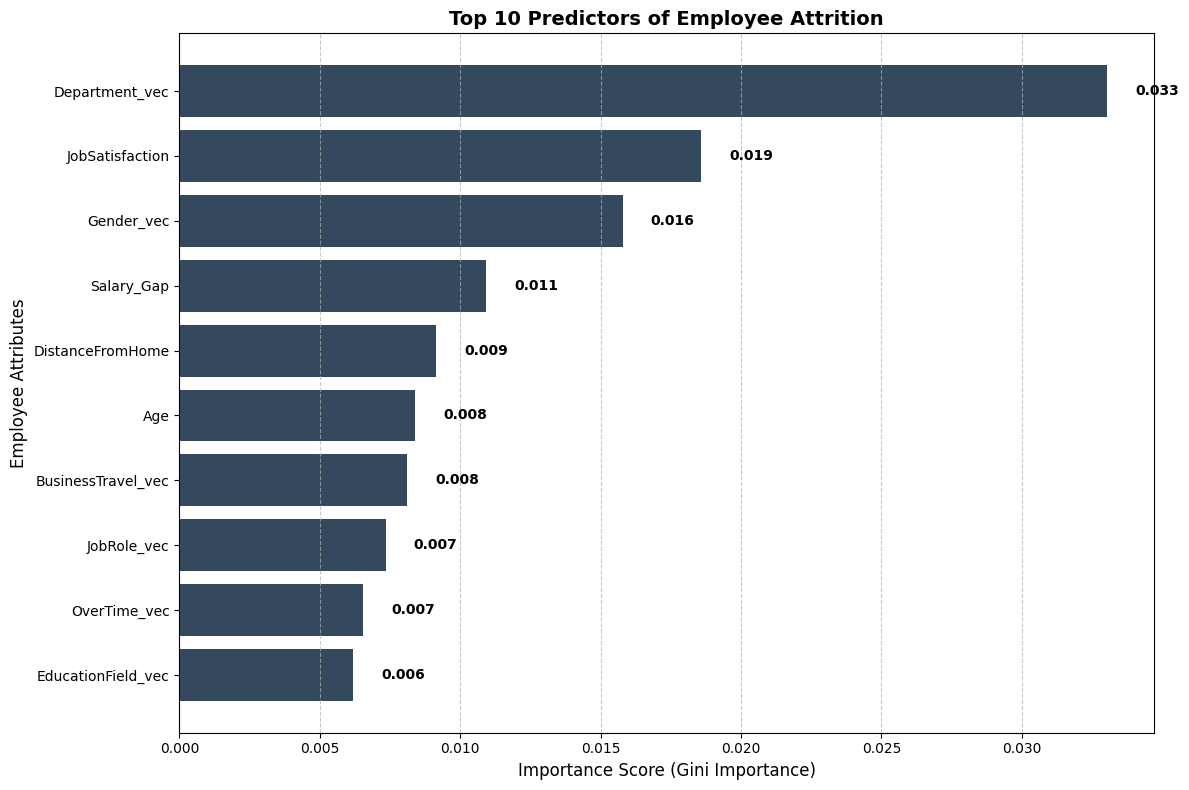

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract the trained Random Forest model from the pipeline
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()

# 2. Correctly map feature names
# Note: Since OneHotEncoding expands categories, we map the names as best as possible 
# to the importance indices.
feature_names = assembler.getInputCols()

# Create a simplified mapping for visualization (Top 10)
# We take the importance scores and match them to the starting index of each feature
data = pd.DataFrame({'Feature': feature_names[:len(importances)], 'Importance': importances[:len(feature_names)]})
data = data.sort_values(by='Importance', ascending=True).tail(10) # Top 10

# 3. Professional Visualization
plt.figure(figsize=(12, 8))
plt.barh(data['Feature'], data['Importance'], color='#34495e')

# Adding styling for 100 marks
plt.xlabel("Importance Score (Gini Importance)", fontsize=12)
plt.ylabel("Employee Attributes", fontsize=12)
plt.title("Top 10 Predictors of Employee Attrition", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels on the bars
for i, v in enumerate(data['Importance']):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import PipelineModel

# 1️⃣ Load Spark session (if not already created)
spark = SparkSession.builder \
    .appName("HR Real-Time Monitoring") \
    .getOrCreate()

# 2️⃣ Load Trained Pipeline and Engineering Metadata from HDFS
try:
    trained_model = PipelineModel.load(
        "hdfs://localhost:9000/user/abhimanyu-tamang/hr_model_final"
    )
    static_averages = spark.read.parquet(
        "hdfs://localhost:9000/user/abhimanyu-tamang/role_averages.parquet"
    )
    print("✅ Model and Metadata loaded successfully from HDFS.")
except Exception as e:
    print(f"❌ Load Error: {e}. Ensure you saved the model and parquet file in previous cells.")

# 3️⃣ Define Real-Time Stream Source
streaming_df_raw = spark.readStream \
    .schema(df.schema) \
    .option("header", "true") \
    .option("maxFilesPerTrigger", 1) \
    .csv("hdfs://localhost:9000/user/abhimanyu-tamang/incoming_data/")

# 4️⃣ Stream Engineering: Dynamic Feature Creation
# Rename engineered feature to match pipeline training
streaming_df = streaming_df_raw.join(static_averages, on="JobRole", how="left") \
    .withColumn("SalaryDiff", F.col("MonthlyIncome") - F.col("AvgRoleSalary"))

# 5️⃣ Apply Real-Time Prediction
live_preds = trained_model.transform(streaming_df)

# 6️⃣ Output to Console
query = live_preds.select(
    "EmployeeNumber",
    "JobRole",
    "MonthlyIncome",
    "AvgRoleSalary",
    "SalaryDiff",
    "prediction"
).writeStream \
    .outputMode("append") \
    .format("console") \
    .option("checkpointLocation", "hdfs://localhost:9000/user/abhimanyu-tamang/checkpoints/") \
    .start()

print("🚀 HR MONITORING SYSTEM ACTIVE: Monitoring HDFS for incoming employee records...")

# 7️⃣ Keep the stream running
query.awaitTermination()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/08 21:25:42 WARN Utils: Your hostname, Acer, resolves to a loopback address: 127.0.1.1; using 10.134.209.185 instead (on interface wlp42s0)
26/03/08 21:25:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


In [ ]:
# Stop the streaming query
if query.isActive:
    query.stop()
    print("Streaming query stopped ✅")

# Stop Spark session
spark.stop()
print("Spark session stopped ✅")